In [1]:
import torch
import joblib
import numpy as np
import pandas as pd
import concurrent.futures
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.stats import skew, kurtosis
from astropy.timeseries import BoxLeastSquares
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

In [2]:
BASELINE_DAYS = 270.0 

def extract_features_from_flux(flux_1d, baseline_days=BASELINE_DAYS):
    """
    Same feature set as before, but operates on the pre-baked 50k-point
    median-centred flux from cnn_dataset.pt. Reconstructs a time axis in
    days by assuming a fixed observation baseline.
    """
    y = flux_1d.astype(float)
    n = len(y)
    cadence = baseline_days / n
    t_days  = np.linspace(0, baseline_days, n)

    # --- Noise estimate ---
    sigma = float(np.nanstd(y))

    pcts = np.nanpercentile(y, [1, 5, 10, 50, 90, 95, 99])

    features = {
        "skew":                      float(skew(y, nan_policy="omit")),
        "kurtosis":                  float(kurtosis(y, nan_policy="omit")),
        "negative_outlier_fraction": float(np.mean(y < -3 * sigma)) if sigma > 0 else np.nan,
    }

    # --- Flare features ---
    positive  = np.clip(y, 0.0, None)
    above_3   = y > 3.0 * sigma
    above_5   = y > 5.0 * sigma
    longest_run, current_run = 0, 0
    for flag in above_3:
        current_run = (current_run + 1) if flag else 0
        longest_run = max(longest_run, current_run)

    features.update({
        "flare_p99_snr":                    float(np.nanpercentile(y, 99) / sigma) if sigma > 0 else np.nan,
        "flare_positive_fraction_3sigma":   float(np.mean(above_3)),
        "flare_longest_duration_3sigma_days": float(longest_run * cadence),
    })

    # --- BLS features (periods in real days via reconstructed time axis) ---
    try:
        periods   = np.geomspace(2.0, 100.0, 160)
        durations = np.array([0.04, 0.08, 0.12, 0.16, 0.32, 0.64])
        dy_arr    = np.full_like(y, max(sigma, 1.0))
        result    = BoxLeastSquares(t_days, y, dy=dy_arr).power(
                        periods, durations, objective="snr")
        power     = np.where(np.isfinite(result.power), result.power, np.nan)
        if np.all(np.isnan(power)):
            raise ValueError
        best      = int(np.nanargmax(power))
        depth     = float(np.ravel(result.depth)[best])
        depth_err = float(np.ravel(result.depth_err)[best])
        bls = {
            "bls_power":        float(power[best]),
            "bls_depth_ppm":    depth,
            "bls_depth_snr":    float(abs(depth) / depth_err) if depth_err > 0 else np.nan,
        }
        bls = {k: v if np.isfinite(v) else np.nan for k, v in bls.items()}
    except Exception:
        bls = {k: np.nan for k in
               ["bls_power",
                "bls_depth_ppm", "bls_depth_snr"]}

    features.update(bls)
    return features

In [3]:
def build_feature_table_from_pt(pt_path="cnn_dataset.pt", max_workers=4):
    """
    Loads the pre-baked tensor cache and extracts the hand-crafted feature
    vector from each light curve. The underlying flux is identical to what
    the CNN sees, so train/val splits are directly comparable.
    """
    data    = torch.load(pt_path, map_location="cpu")
    X_all   = data['X'].squeeze(1).numpy()   # (N, 50000)
    y_all   = data['y'].numpy()              # (N, 2): [is_flare, is_transit]
    ids     = data['ids']

    def _worker(i):
        row = extract_features_from_flux(X_all[i])
        row['system_id']   = ids[i]
        # Store the individual indicators explicitly
        row['has_flare']   = int(y_all[i, 0])
        row['has_transit'] = int(y_all[i, 1])
        return row

    with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as ex:
        rows = list(tqdm(ex.map(_worker, range(len(X_all))),
                         total=len(X_all), desc="Extracting features"))

    return pd.DataFrame(rows)

feature_df = build_feature_table_from_pt("../../data/models/cnn_dataset.pt")
print(feature_df.shape)

# Check the distribution of your two new binary target columns instead!
print("\nFlare distribution:")
print(feature_df["has_flare"].value_counts())

print("\nTransit distribution:")
print(feature_df["has_transit"].value_counts())

Extracting features: 100%|██████████| 1485/1485 [00:26<00:00, 55.14it/s]

(1485, 12)

Flare distribution:
has_flare
1    757
0    728
Name: count, dtype: int64

Transit distribution:
has_transit
0    743
1    742
Name: count, dtype: int64


In [4]:
# Load the exact same indices the CNN used
split       = torch.load("../../data/models/split_indices.pt")
train_idx   = split['train_indices']
val_idx     = split['val_indices']

# Strip out both label columns from features
feature_cols = [c for c in feature_df.columns if c not in {'system_id', 'has_flare', 'has_transit'}]
X_all_feat   = feature_df[feature_cols].values

# Extract a 2D array target: shape (N, 2)
y_all_labels = feature_df[['has_flare', 'has_transit']].values

X_train, X_val = X_all_feat[train_idx], X_all_feat[val_idx]
y_train, y_val = y_all_labels[train_idx], y_all_labels[val_idx]

print(f"Train: {len(X_train)}  |  Val: {len(X_val)}")

Train: 1188  |  Val: 297


In [5]:
rf_clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )),
])

rf_clf.fit(X_train, y_train)

# Evaluate
# Evaluate
y_pred = rf_clf.predict(X_val)  # Shape is now (N_val, 2)

targets = ['has_flare', 'has_transit']
for idx, name in enumerate(targets):
    print(f"Metrics for: {name}")
    
    print("Confusion Matrix:")
    print(pd.DataFrame(
        confusion_matrix(y_val[:, idx], y_pred[:, idx], labels=[0, 1]),
        index=["true_no", "true_yes"],
        columns=["pred_no", "pred_yes"]
    ))
    
    print("\nClassification Report:")
    print(classification_report(y_val[:, idx], y_pred[:, idx], target_names=["no", "yes"]))

Metrics for: has_flare
Confusion Matrix:
          pred_no  pred_yes
true_no       158         1
true_yes       15       123

Classification Report:
              precision    recall  f1-score   support

          no       0.91      0.99      0.95       159
         yes       0.99      0.89      0.94       138

    accuracy                           0.95       297
   macro avg       0.95      0.94      0.95       297
weighted avg       0.95      0.95      0.95       297

Metrics for: has_transit
Confusion Matrix:
          pred_no  pred_yes
true_no       110        37
true_yes       59        91

Classification Report:
              precision    recall  f1-score   support

          no       0.65      0.75      0.70       147
         yes       0.71      0.61      0.65       150

    accuracy                           0.68       297
   macro avg       0.68      0.68      0.68       297
weighted avg       0.68      0.68      0.68       297



In [6]:
# ── SAVE FEATURE COLS TO TXT ───────────────────────────────────────────────
with open("../../data/models/feature_columns.txt", "w") as f:
    for col in feature_cols:
        f.write(f"{col}\n")
print("Saved feature columns to feature_columns.txt")
# ───────────────────────────────────────────────────────────────────────────

Saved feature columns to feature_columns.txt


In [7]:
# --- Build full_analysis for the validation set ---
df_meta = pd.read_csv("../../data/input_labels/paired_simulation_labels_combined.csv")

val_system_ids = feature_df.iloc[val_idx]['system_id'].values
y_pred_val     = rf_clf.predict(X_val)       # Shape: (N_val, 2)
y_proba_val    = rf_clf.predict_proba(X_val)  # List of 2 arrays: [flare_probs, transit_probs]

# Extract the probability of the event occurring (class 1) for each target
p_flare   = y_proba_val[0][:, 1]
p_transit = y_proba_val[1][:, 1]

# Build a explicit multi-label evaluation dataframe
results_df = pd.DataFrame({
    'system_id':           val_system_ids,
    'true_has_flare':      y_val[:, 0],
    'true_has_transit':    y_val[:, 1],
    'pred_has_flare':      y_pred_val[:, 0],
    'pred_has_transit':    y_pred_val[:, 1],
    'proba_flare':         p_flare,
    'proba_transit':       p_transit
})

# Merge in the physical parameters (transit_radius_earth, flare_amplitude, drift, etc.)
full_analysis = pd.merge(results_df, df_meta, on='system_id', how='left')

# Save out to disk
full_analysis.to_csv("../../data/models/rf_full_analysis.csv", index=False)

print(f"Saved rf_full_analysis.csv ({len(full_analysis)} rows)")
print("\nAvailable columns inside full_analysis:")
print(full_analysis.columns.tolist())

Saved rf_full_analysis.csv (297 rows)

Available columns inside full_analysis:
['system_id', 'true_has_flare', 'true_has_transit', 'pred_has_flare', 'pred_has_transit', 'proba_flare', 'proba_transit', 'master_seed', 'anomaly_class', 'label_has_flares', 'label_has_transit', 'star_mass', 'star_teff', 'star_logg', 'flare_amplitude', 'transit_period', 'transit_radius_earth', 'drift']


In [8]:
#full_analysis = pd.read_csv("../../data/models/rf_full_analysis.csv")

In [9]:
# Save — joblib is the standard for sklearn; it handles numpy arrays efficiently
joblib.dump(rf_clf, "../../data/models/rf_checkpoint.joblib")

['../../data/models/rf_checkpoint.joblib']

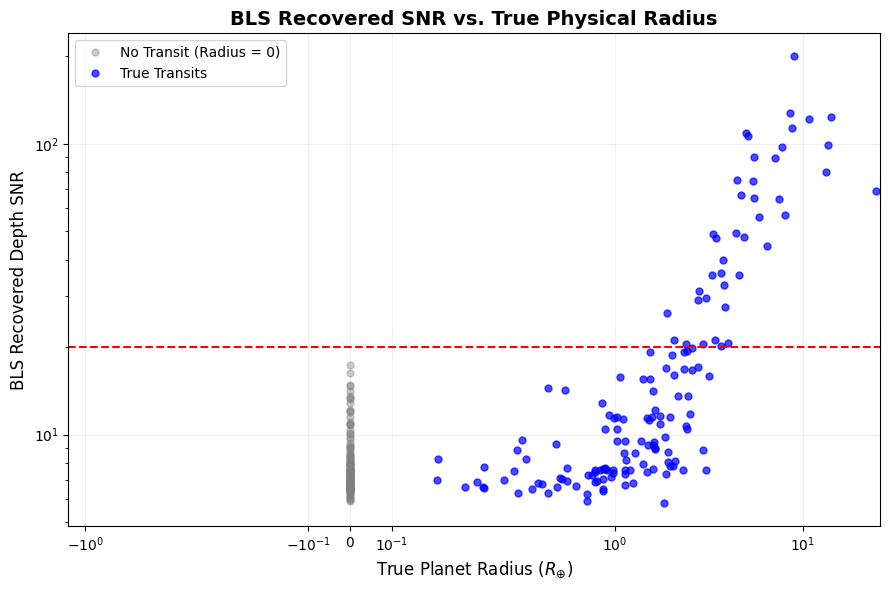

In [10]:
# 1. Merge the planet radius from your dataframe into your validation features
val_df = feature_df.iloc[val_idx].copy()
val_results = val_df.merge(full_analysis[['system_id', 'transit_radius_earth']], on='system_id', how='left')

# 2. Clean up any missing BLS values
val_results['bls_depth_snr'] = val_results['bls_depth_snr'].fillna(0)

# --- NEW: Split the data into transits and non-transits ---
transits = val_results[val_results['transit_radius_earth'] > 0]
non_transits = val_results[val_results['transit_radius_earth'] == 0]

# 3. Create the scatter plot
plt.figure(figsize=(9, 6))

# Plot NON-transits first (so they are in the background)
plt.plot(
    non_transits['transit_radius_earth'],
    non_transits['bls_depth_snr'],
    linestyle='None',
    marker='o',
    color='gray',
    alpha=0.4,
    markersize=5,
    label='No Transit (Radius = 0)'
)

# Plot true transits on top
plt.plot(
    transits['transit_radius_earth'],
    transits['bls_depth_snr'],
    linestyle='None',
    marker='o',
    color='blue',
    alpha=0.7,
    markersize=5,
    label='True Transits'
)

plt.xlabel('True Planet Radius ($R_{\oplus}$)', fontsize=12)
plt.ylabel('BLS Recovered Depth SNR', fontsize=12)
plt.title('BLS Recovered SNR vs. True Physical Radius', fontweight='bold', fontsize=14)
plt.legend(loc='upper left')
plt.grid(alpha=0.2)

plt.axhline(y=20.0, color='red', linestyle='--', label='SNR = 20 separation')

# Set Y-axis to log scale
plt.yscale('log')

# Set X-axis to symlog (symmetrical log) to safely plot 0
# linthresh=0.5 means everything between -0.5 and 0.5 is linear, outside is log
plt.xscale('symlog', linthresh=0.5) 


plt.tight_layout()
plt.savefig('../img/bls_radius_vs_snr.png', bbox_inches='tight')
plt.show()